# ModelTester — one notebook to test any model on any feature set

This notebook follows the brief's required structure:
1. **Describe the model & data**, with summary statistics (observation counts for estimation and forecast periods)
2. **RMSE chart: model vs AR1**, numbers printed on the bars
3. **Demonstrate the out-of-sample approach**
4. **Plots of the series used in the model**

…plus an extra section on **overfitting & the "lag" look** of the error charts.

**How to use it:** change `FEATURES` (Step 1) and `MODEL_NAME` (Step 2), then *Run All*.
Everything runs through the exact same engine and model classes as the official
pipeline (`src/`), so nothing here can drift from the real results — with the
default settings the numbers reproduce `reports/metrics_overall.csv` exactly.

## Step 1 — Import the dataset & choose features

The weekly table is built by the pipeline (`python run.py fetch build`): every
daily series sampled to Fridays (last value on or before each Friday), target =
log USDZAR, features known at each Friday.

**To test a different dataset/feature combination: edit `FEATURES` below.**

In [1]:
# Auto-reload src/ modules when they change on disk
%load_ext autoreload
%autoreload 2
%matplotlib widget

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src import config, diagnostics as dx, plots

weekly = pd.read_parquet(config.DATA_PROCESSED / 'weekly.parquet')

# The feature set under test. Default = the official list. Try subsets, e.g.
# FEATURES = ['d4_log_gold', 'rate_spread', 'mr_gap']
FEATURES = list(config.FEATURE_COLS)
print('features under test:', FEATURES)

features under test: ['d4_log_gold', 'd4_log_platinum', 'd4_log_brent', 'd4_log_dxy', 'd4_vix', 'd4_credit', 'rate_spread', 'mr_gap']


**What each variable actually is** — the full catalogue (from
`config.FEATURE_INFO`), with a tick showing what the current `FEATURES`
subset includes. Use the left-column names when editing `FEATURES` above.

In [2]:
catalogue = pd.DataFrame(
    config.FEATURE_INFO, index=['dataset / series', 'source', 'transform']
).T
catalogue['in current test'] = ['✓' if f in FEATURES else '' for f in catalogue.index]
catalogue

,dataset / series,source,transform,in current test
d4_log_gold,"Gold price, US dollars per fine ounce",SARB MARKET_RATES: GDPL201.B.A,4-week log change,✓
d4_log_platinum,"Platinum price, USD per troy ounce",local CSV: plt_per_troy_ounce.csv,4-week log change,✓
d4_log_brent,Brent crude oil price,FRED: DCOILBRENTEU,4-week log change,✓
d4_log_dxy,Broad trade-weighted US dollar index,FRED: DTWEXBGS,4-week log change,✓
d4_vix,CBOE VIX (US equity volatility index),FRED: VIXCLS,4-week change,✓
d4_credit,US credit spread: Moody's Baa − 10y UST,FRED: DBAA minus DGS10,4-week change,✓
rate_spread,SA 3m JIBAR minus US 3m Treasury yield,SARB: MMSD502.D.A / FRED: DGS3MO,level,✓
mr_gap,Log USDZAR gap to its 52-week average,derived from SARB: EXCX135.B.A,level (deviation),✓


**Summary statistics** (brief requirement). Note the expanding window: the model
is first *estimated* on the pre-2021 sample, then re-estimated every Friday, so
by the last origin it trains on almost the whole table.

In [3]:
dx.obs_counts(weekly)

,fridays,first,last,usdzar mean,usdzar min,usdzar max
estimation (pre-2021),523,2010-12-24,2020-12-25,12.08,6.62,19.07
forecast window (2021-25),261,2021-01-01,2025-12-26,17.16,13.57,19.74
full weekly table,812,2010-12-24,2026-07-10,13.86,6.62,19.74


In [4]:
weekly[['usdzar', config.TARGET_COL, *FEATURES]].describe().round(3)

,usdzar,log_usdzar,d4_log_gold,d4_log_platinum,d4_log_brent,d4_log_dxy,d4_vix,d4_credit,rate_spread,mr_gap
count,812.000,812.000,812.000,812.000,812.000,812.000,812.000,812.000,812.000,812.000
mean,13.862,2.592,0.005,-0.000,-0.001,0.001,-0.010,-0.007,4.679,0.026
std,3.496,0.283,0.044,0.073,0.119,0.014,5.753,0.182,1.333,0.069
min,6.622,1.890,-0.158,-0.450,-0.830,-0.041,-29.610,-0.960,2.300,-0.133
25%,11.205,2.416,-0.022,-0.047,-0.059,-0.009,-2.603,-0.090,3.287,-0.024
50%,14.312,2.661,0.003,-0.001,0.004,0.000,-0.225,-0.015,4.980,0.031
75%,16.778,2.820,0.031,0.043,0.058,0.011,2.050,0.060,5.683,0.071
max,19.745,2.983,0.157,0.398,0.756,0.065,48.960,2.140,7.180,0.250


## Step 2 — Select the model

All models share one interface: `fit(train_df)` learns from data up to the
origin Friday; `predict(origin_row)` returns log USDZAR 4 weeks ahead.

| name | idea |
|---|---|
| `RandomWalk` | forecast = today (no features) |
| `RW+Drift` | today + average weekly trend (no features) |
| `AR1` | **official benchmark**: OLS of level in 4 weeks on level today |
| `OLS` | regression of the 4-week change on `FEATURES` |
| `Ridge` | same, coefficients shrunk toward 0 (CV-tuned inside the training window) |
| `Lasso` | same, weak features shrunk to exactly 0 (CV-tuned inside the training window) |
| `SVM` | support-vector regression, RBF kernel — the only NONLINEAR model (CV-tuned) |
| `Lasso+RW` | Lasso + carries part of its latest residual forward (persistence ρ estimated in-window; ρ=1 = literal random walk on residuals) |

**Change `MODEL_NAME` to test another model.** It will be compared against AR1.

In [5]:
from src.models.benchmarks import AR1Level, RandomWalk, RandomWalkDrift
from src.models.regressions import (
    FundamentalsOLS, LassoModel, LassoResidualRW, RidgeModel, SVMModel,
)

MODEL_NAME = 'Lasso+RW'   # <-- change here

def make_model():
    factories = {
        'RandomWalk': lambda: RandomWalk(),
        'RW+Drift':   lambda: RandomWalkDrift(),
        'AR1':        lambda: AR1Level(),
        'OLS':        lambda: FundamentalsOLS(features=FEATURES),
        'Ridge':      lambda: RidgeModel(features=FEATURES),
        'Lasso':      lambda: LassoModel(features=FEATURES),
        'SVM':        lambda: SVMModel(features=FEATURES),
        'Lasso+RW':   lambda: LassoResidualRW(features=FEATURES),
        # literal random-walk-on-residuals (rho forced to 1) for comparison:
        # 'Lasso+RW1': lambda: LassoResidualRW(features=FEATURES, rho=1.0),
    }
    return factories[MODEL_NAME]()

make_model()  # sanity check it constructs

## Step 3 — Demonstrate the out-of-sample approach

Two demonstrations, one structural and one experimental.

**(a) The engine physically truncates the data at each origin.** Below is the
actual source code of the backtest loop — the line
`train_df = df.loc[df.index <= origin]` is the entire guarantee: a model is
handed only rows up to its forecast Friday, then asked about 4 weeks later.

In [6]:
import inspect
from src.backtest import run_backtest
print(inspect.getsource(run_backtest))

def run_backtest(
    df: pd.DataFrame,
    models: list[Model],
    origins: pd.DatetimeIndex,
    horizon: int = HORIZON_WEEKS,
) -> pd.DataFrame:
    """Generic engine: any weekly table, any models, any origin list.

    Kept free of file I/O and of model-specific logic so the no-look-ahead
    test in tests/test_backtest.py exercises EXACTLY the code path used in
    production runs.
    """
    rows: list[dict] = []
    for origin in origins:
        # THE pseudo-real-time line: everything a model receives derives
        # from this truncation at the origin Friday.
        train_df = df.loc[df.index <= origin]
        origin_row = df.loc[origin]

        # The grid is regular W-FRI, so origin + h weeks is again a Friday.
        target_date = origin + pd.Timedelta(weeks=horizon)
        # Actual outcome, if that Friday is already in the table. Late-2025
        # origins whose target falls past the data edge keep NaN and are
        # simply excluded from error metrics.
        a

**(b) Live proof:** corrupt every row AFTER one origin with garbage and re-run —
the forecast made at that origin must not change at all. (The test suite runs
this same check for all models at several origins: `tests/test_backtest.py`.)

In [7]:
import numpy as np

origin_pos = 600                       # any Friday in the table
one_origin = weekly.index[[origin_pos]]

clean = run_backtest(weekly, [make_model()], one_origin)

corrupted = weekly.copy()
future = corrupted.index > one_origin[0]
corrupted.loc[future, :] = np.random.default_rng(0).normal(100, 50, size=(future.sum(), weekly.shape[1]))
dirty = run_backtest(corrupted, [make_model()], one_origin)

same = clean['forecast_log'].iloc[0] == dirty['forecast_log'].iloc[0]
print(f"origin {one_origin[0].date()}: forecast unchanged after corrupting the future -> {same}")
assert same, 'LOOK-AHEAD BUG!'

  backtest at 2022-06-24 (train n=601)


  backtest at 2022-06-24 (train n=601)
origin 2022-06-24: forecast unchanged after corrupting the future -> True


## Step 4 — Run the walk-forward test

Expanding window over every Friday origin 2021–2025: refit → forecast 4 weeks →
record. We run the chosen model **and AR1** through the same loop.

*Takes ~2–4 min for Lasso/Ridge (261 origins × a small grid-search each).
Set `ORIGIN_EVERY = 2` for a quick half-resolution pass while experimenting.*

In [8]:
from src.backtest import friday_origins

ORIGIN_EVERY = 1                        # 1 = official grid; 2 = every other Friday (faster)
origins = friday_origins(weekly)[::ORIGIN_EVERY]

results = run_backtest(weekly, [make_model(), AR1Level()], origins)
results = results.dropna(subset=['actual'])
print(f"{results['origin'].nunique()} origins, models: {list(results['model'].unique())}")

  backtest at 2021-01-01 (train n=524)


  backtest at 2021-02-05 (train n=529)


  backtest at 2021-03-05 (train n=533)


  backtest at 2021-04-02 (train n=537)


  backtest at 2021-05-07 (train n=542)


...

  backtest at 2025-09-05 (train n=768)


  backtest at 2025-10-03 (train n=772)


  backtest at 2025-11-07 (train n=777)


  backtest at 2025-12-05 (train n=781)


261 origins, models: ['Lasso+RW', 'AR1']


## Step 5 — Performance: RMSE vs the AR1 benchmark

Bar chart with the numbers printed on the bars (brief requirement), then the
full metric table and the year-by-year comparison.

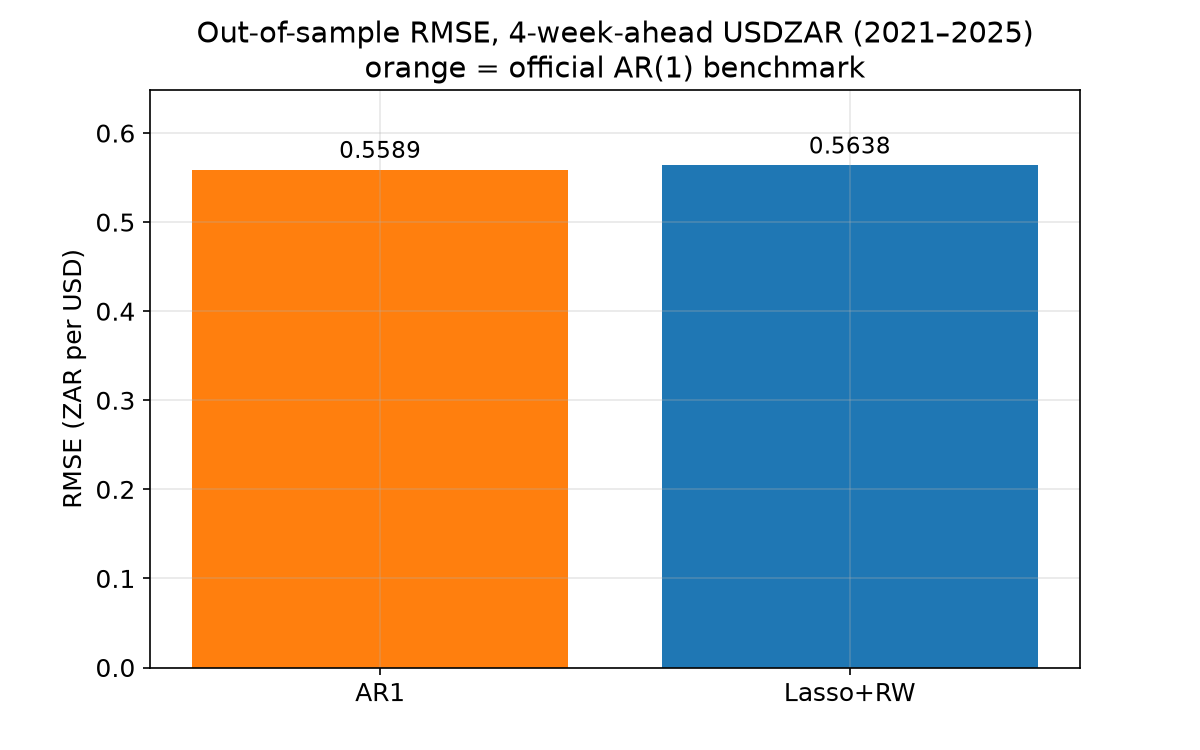

In [9]:
from src.evaluate import overall_table
overall = overall_table(results)
plots.fig_rmse_bar(overall);

In [10]:
dx.summary(results, MODEL_NAME).round(4) if MODEL_NAME != 'AR1' else overall.round(4)

,rmse,mae,hit_rate,n,rmse_vs_ar1,dm_stat_vs_ar1,dm_pvalue
model,,,,,,,
Lasso+RW,0.5638,0.4659,0.4636,261.0,1.0088,0.3513,0.7256


In [11]:
dx.per_year_vs_benchmark(results, MODEL_NAME).round(4)

model,AR1,Lasso+RW,Lasso+RW / AR1
year,,,
2021,0.5068,0.5157,1.0174
2022,0.6937,0.6810,0.9817
2023,0.6546,0.6320,0.9655
2024,0.4420,0.4606,1.0420
2025,0.4481,0.4989,1.1134


## Step 6 — Plots of the series used in the model

The target with the evaluation window shaded, then each feature in `FEATURES`
(orange band = forecast window).

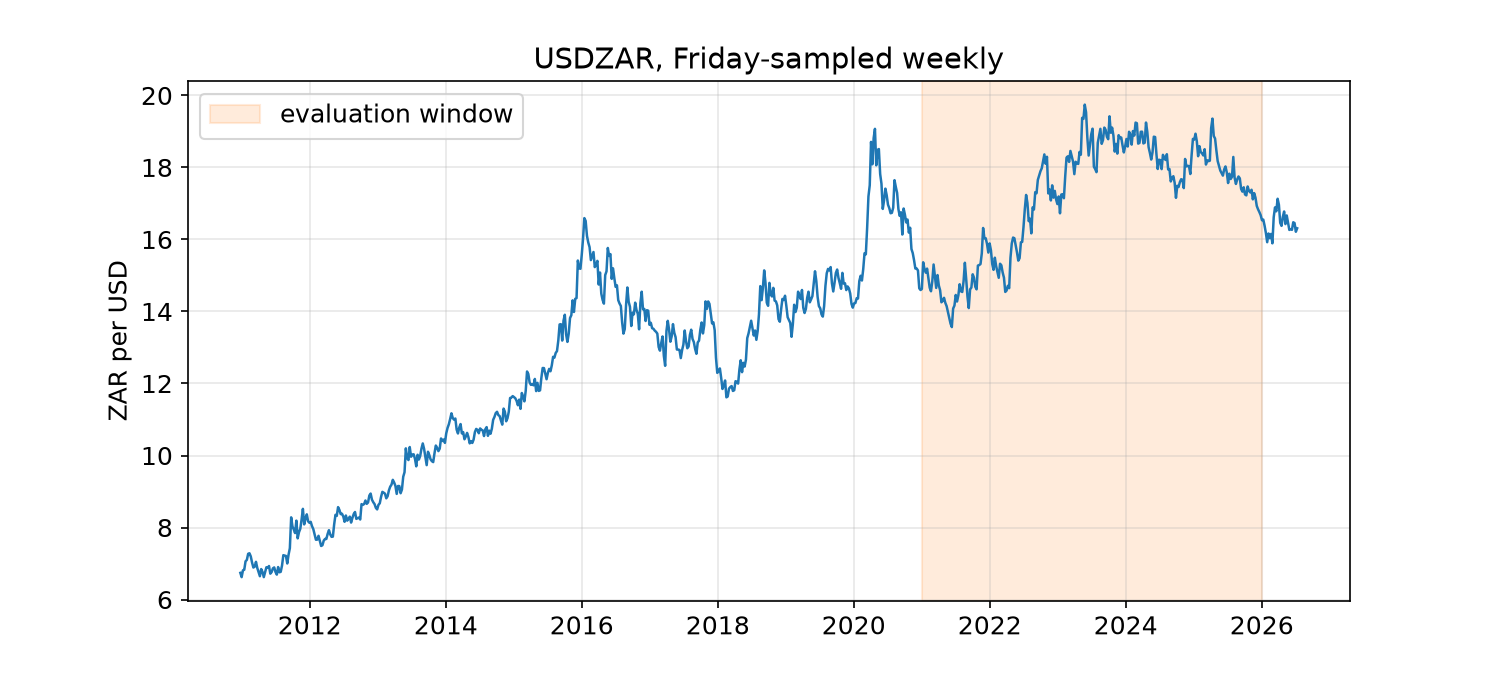

In [12]:
plots.fig_history(weekly);

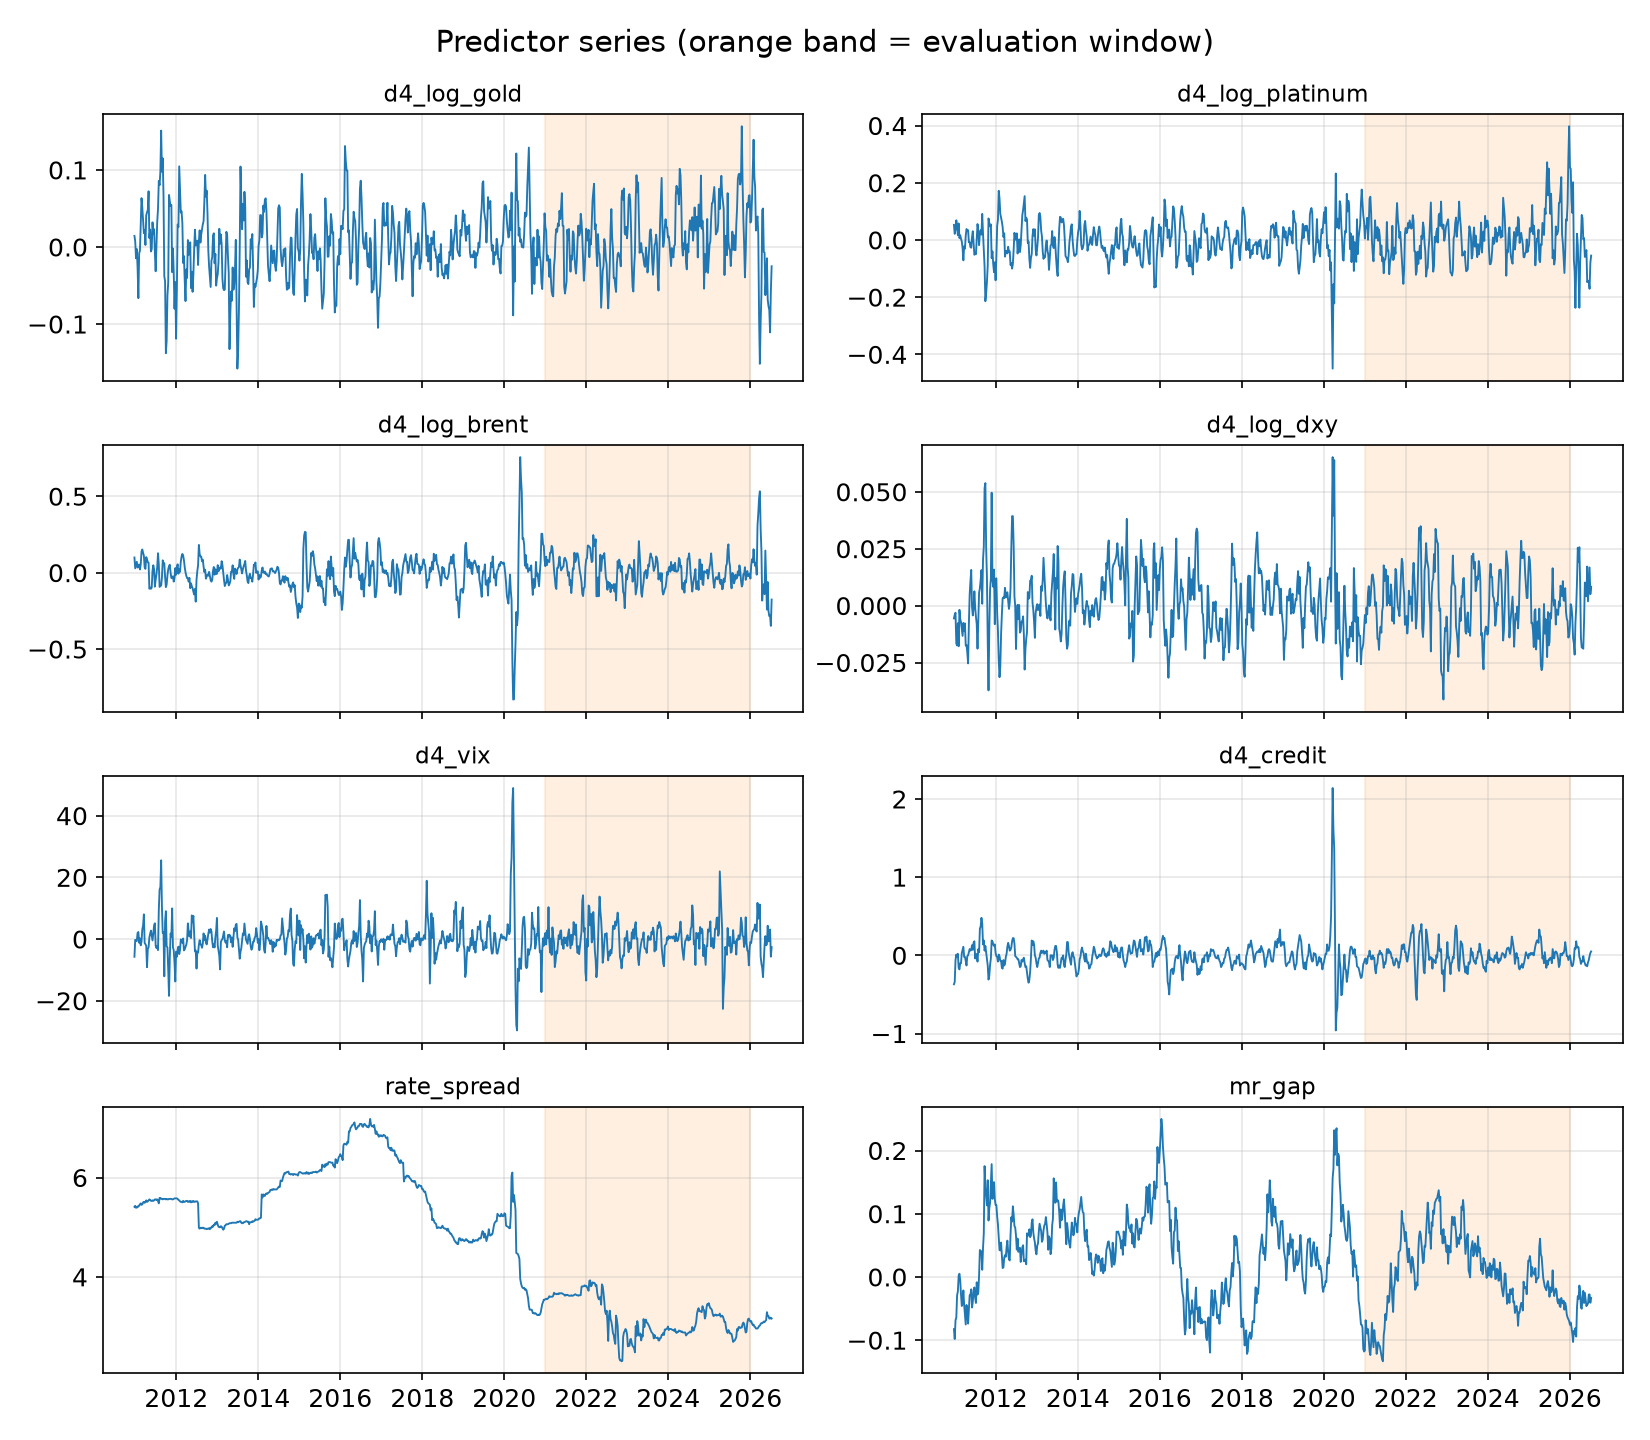

In [13]:
plots.fig_predictors(weekly, cols=FEATURES);

**Interactive overall-performance view** — every forecast on one chart:
**actual** (black solid), **AR1** (orange dashed), chosen model (blue solid),
each plotted at the date the forecast was *for*. Drag the two slider handles to
zoom into any window — the chart redraws and the metric table underneath
recomputes **for that window only** (same metric code as the official
evaluation, so the full-range numbers match Step 5).

Zoomed out, both forecast lines hug the actual — that closeness *is* the core
finding (every model forecasts ≈ no change). Zoom into a few months to see
where the two models actually disagree.

*(No slider showing? Run `pip install ipywidgets` in the venv and restart
Jupyter.)*

In [14]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

target_dates = sorted(pd.to_datetime(results['target_date'].unique()))
window_slider = widgets.SelectionRangeSlider(
    options=[(d.strftime('%Y-%m-%d'), d) for d in target_dates],
    index=(0, len(target_dates) - 1),
    description='window',
    continuous_update=False,          # recompute on release, not while dragging
    layout=widgets.Layout(width='95%'),
)

# Previous-figure holder. A plain dict OUTSIDE the callback, because
# @interact calls the function immediately during decoration — before the
# name `forecast_view` even exists — so state can't live on the function.
_view = {'fig': None}

@widgets.interact(window=window_slider)
def forecast_view(window):
    start, end = window
    # Close the PREVIOUS live canvas (not the new one!) so figures don't
    # pile up in memory as you drag the slider.
    if _view['fig'] is not None:
        plt.close(_view['fig'])
    # ioff: stop ipympl auto-displaying the figure — we display its live
    # canvas ourselves below, exactly once.
    with plt.ioff():
        fig = dx.fig_forecast_comparison(results, MODEL_NAME, start, end)
    _view['fig'] = fig

    # Crosshair: move the mouse over the chart to see the date + the value
    # of EVERY line at that point (needs %matplotlib widget, set in cell 1).
    dx.attach_crosshair(fig)

    # fig.canvas is the LIVE widget; display(fig) would be a static picture.
    display(fig.canvas)
    display(dx.window_metrics(results, MODEL_NAME, start, end))
    # Side-by-side values (last 12 target dates of the window). Spot the
    # "one-month lag" numerically: every forecast ~= 'spot at origin' —
    # the models carry the origin-Friday rate forward 4 weeks.
    display(dx.window_table(results, MODEL_NAME, start, end, rows=12))

interactive(children=(SelectionRangeSlider(continuous_update=False, description='window', index=(0, 260), layo…

## Step 7 — Overfitting & the "lag" look of the error charts

When you plot |error| of the model and AR1 by origin, the two lines look almost
identical and seem to move in slow waves. Three checks below let you verify
**why**, yourself:

1. **Error correlation** — if it is ≈1.0, the models make essentially the *same*
   errors. That happens because both predict very small moves, so each error is
   ≈ (minus) the *actual* 4-week move — the wiggles you see are the rand itself,
   not model behaviour.
2. **Predicted-vs-actual scatter** — if the cloud hugs the horizontal axis, the
   model barely commits to any move: the *opposite* of overfitting in its
   forecasts. (Compare `sd(pred)/sd(actual)` across models.)
3. **Error autocorrelation** — consecutive weekly origins forecast 4-week windows
   that overlap by 3 weeks, so neighbouring errors share most of their outcome.
   Theory: autocorrelation ≈ high at lags 1–3, ≈ 0 from lag 4. That overlap is
   the whole "lag/wave" effect — and it is also exactly why our Diebold–Mariano
   test uses an autocorrelation-robust variance.
4. **In-sample vs out-of-sample RMSE** — the classic overfitting test: a ratio
   well above 1 means the model memorised noise. (Compare OLS to Lasso here.)

corr(Lasso+RW errors, AR1 errors) = 0.9983


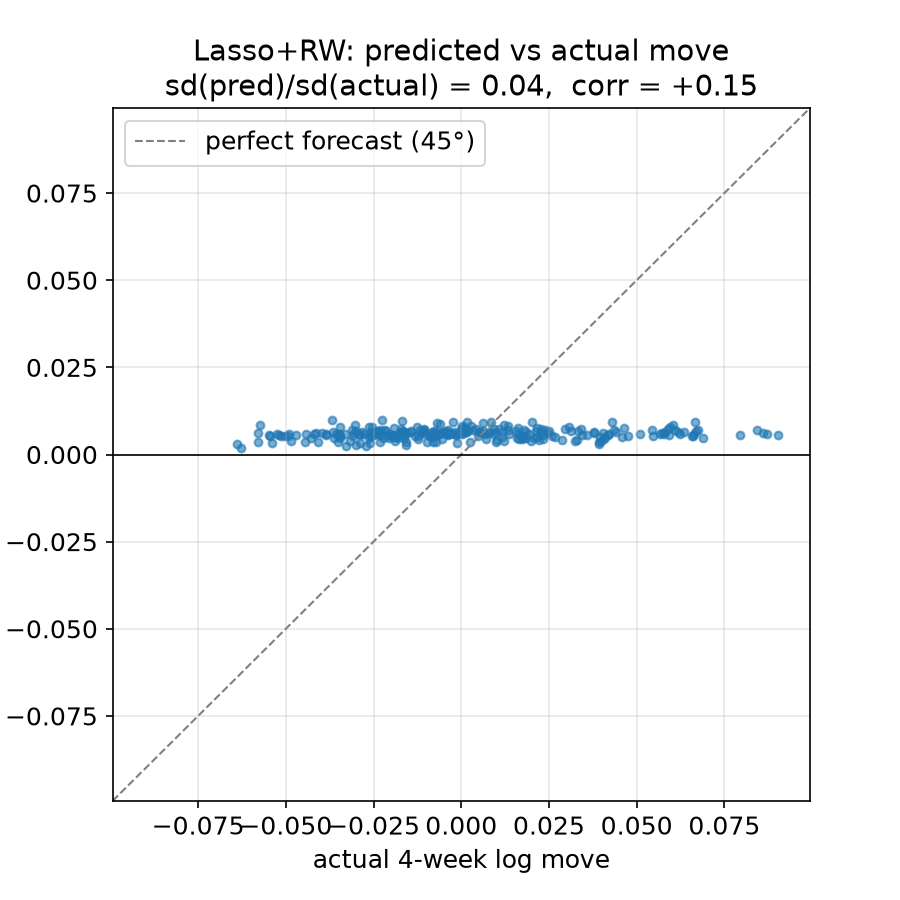

In [15]:
print(f"corr({MODEL_NAME} errors, AR1 errors) = {dx.error_correlation(results, MODEL_NAME):.4f}")
dx.fig_move_scatter(results, MODEL_NAME);

In [16]:
dx.error_autocorr(results, MODEL_NAME)

lag 1w    0.678
lag 2w    0.367
lag 3w    0.069
lag 4w   -0.175
lag 5w   -0.111
lag 6w   -0.073
Name: Lasso+RW error autocorrelation, dtype: float64

In [17]:
# a couple of seconds: one extra fit on the pre-2021 sample
dx.insample_vs_oos(weekly, results, MODEL_NAME, make_model)

,rmse
"in-sample (fit once, pre-2021)",0.5467
out-of-sample (pipeline),0.5638
ratio,1.0311


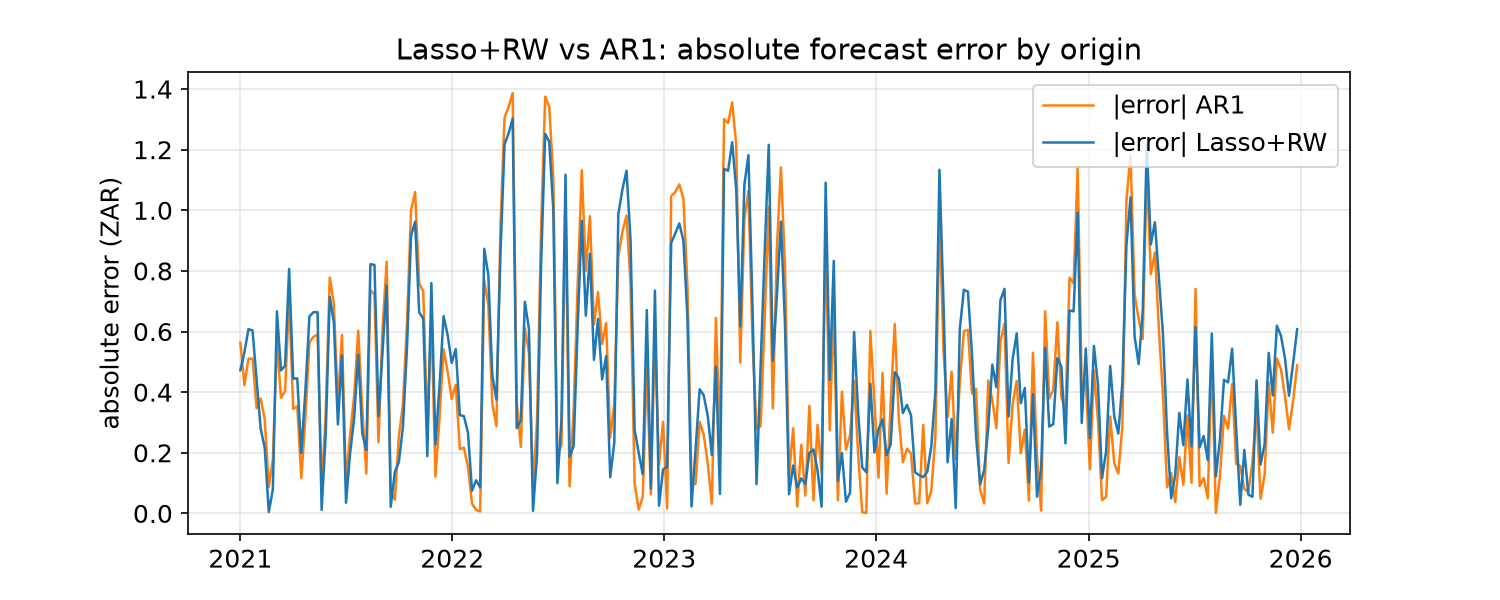

In [18]:
dx.fig_error_timeline(results, MODEL_NAME);   # the chart from the discussion, for reference

## Step 8 — Observations

1. **Nothing beats AR(1) overall.** Our best challenger (Lasso+RW, RMSE 0.5638)
   sits 0.9% behind AR(1) over 261 origins, and the Diebold–Mariano test cannot
   tell them apart (p = 0.73). This is the classic Meese–Rogoff result: at a
   1-month horizon, exchange rates are close to unforecastable.
2. **Every model is a near-random-walk in disguise.** Predicted 4-week moves
   carry only ~1–3% of the volatility of actual moves, and the error series of
   any two models correlate at >0.99 — the error charts mostly display the
   rand's own volatility, echoed one month late. The visible "lag" of forecasts
   behind the actual is exactly this: forecast ≈ origin-Friday spot carried
   4 weeks forward.
3. **Flexibility trades calm years for crisis years.** The fundamentals models
   beat AR(1) in turbulent 2022–23 and lose in calm 2024–25. SVM is the extreme
   case: best model of all in 2022, worst overall, with an in-sample vs
   out-of-sample RMSE ratio of 1.72 — textbook overfitting. Overall ranking
   worsens monotonically with model freedom: benchmarks → Lasso → Ridge → OLS → SVM.
4. **Lasso self-protects; OLS cannot.** Each feature we added (US credit
   spread, platinum) left Lasso's RMSE exactly unchanged — it shrank the
   newcomers to zero — while OLS, forced to fit them, deteriorated every time.
5. **Forecast errors are (slightly) predictable — but backwards.** Lasso+RW
   estimates the 4-week persistence of its own residuals inside each training
   window and finds ρ ≈ −0.05: misses tend to partially reverse. Fading the
   latest error improved RMSE in all five years; forcing ρ = 1 (a literal
   random walk on the residuals) would have amplified errors instead.
6. **Robustness.** Conclusions are unchanged at half origin-resolution
   (`ORIGIN_EVERY = 2`) and with feature subsets — the AR(1)-vs-rest gap is a
   property of the problem, not of our particular configuration.